# LeNet-5 Architecture
Implementação da arquitetura LeNet-5 usando PyTorch. Por enquanto, contém apenas a declaração do modelo.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

class LeNet5(nn.Module):
    def __init__(self):
        super(LeNet5, self).__init__()
        # The input to LeNet-5 is usually 32x32
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=6, kernel_size=5, stride=1),
            nn.ReLU(),            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=16, out_channels=120, kernel_size=5, stride=1),
            nn.ReLU()
        )

        self.classifier = nn.Sequential(
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(),
            nn.Linear(in_features=84, out_features=10)
        )

    def forward(self, x):
        x = self.feature_extractor(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits

## Visualizando os Filtros Iniciais
Nesta seção, instanciamos o modelo e plotamos os pesos (filtros) da primeira camada convolucional `Conv2d` logo após a inicialização. Como a rede ainda não foi treinada, esperamos ver padrões completamente aleatórios.

In [ ]:
# Instancia o modelo
model = LeNet5()

# Extrai os pesos da primeira camada convolucional (self.feature_extractor[0])
weights = model.feature_extractor[0].weight.data.clone().cpu()

print(f"Shape dos pesos da primeira camada: {weights.shape}")

fig, axes = plt.subplots(1, 6, figsize=(15, 3))
for i in range(6):
    # Pegamos o i-ésimo filtro. O shape é [6, 1, 5, 5], então weights[i, 0] é um tensor 5x5
    ax = axes[i]
    ax.imshow(weights[i, 0], cmap='viridis')
    ax.set_title(f"Filtro {i+1}")
    ax.axis('off')

plt.suptitle("Pesos da primeira camada convolucional (Antes do treinamento)")
plt.show()

## Dataset MNIST
Carregando o Dataset MNIST clássico (Dígitos de 0 a 9) e visualizando algumas imagens do conjunto de treinamento.

In [ ]:
# Definimos a sequência de transformações
# Como a LeNet-5 original espera imagens 32x32, aplicamos Resize. 
# ToTensor converte imagens PIL ou ndarray [0, 255] para Tensores Float [0.0, 1.0].
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor()
])

# Download e Carregamento do Dataset
train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)

# Dataset de teste
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

# Função para visualizar as imagens
def imshow(img):
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)), cmap='gray')
    plt.axis('off')
    plt.show()

# Obtendo um lote de dados de treinamento para visualização (Limitando a 8 imagens apenas para ver)
vis_loader = torch.utils.data.DataLoader(train_dataset, batch_size=8, shuffle=True)
dataiter = iter(vis_loader)
images, labels = next(dataiter)

print(f"Tamanho do Lote de Imagens: {images.shape}") # O shape será [Batch_Size, Channels, Height, Width]

# Mostrando imagens usando a grade do torchvision
imshow(torchvision.utils.make_grid(images))
print(f"Labels do Lote: {' '.join(str(label.item()) for label in labels)}")

## Treinamento do Modelo
Aqui configuramos a função de perda (Cross Entropy Loss) e o otimizador (Adam), e iteramos pelo conjunto de dados para atualizar os pesos da nossa rede.

In [ ]:
# Verifica se há GPU disponível e move o modelo para o dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu"))
print(f"Usando o dispositivo: {device}")

# Reinstanciando o modelo para garantir um estado limpo, e enviando para o dispositivo correto
model = LeNet5().to(device)

# Definindo a Função de Perda e o Otimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Número de épocas
num_epochs = 5

# Loop de Treinamento
for epoch in range(num_epochs):
    running_loss = 0.0
    for i, data in enumerate(train_loader, 0):
        # Obter os inputs; data é uma lista de [inputs, labels]
        inputs, labels = data[0].to(device), data[1].to(device)

        # Zera os gradientes dos parâmetros ajustáveis
        optimizer.zero_grad()

        # Forward + Backward + Otimização
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Atualiza a perda acumulada
        running_loss += loss.item()
        
        # Imprime estatísticas a cada 200 mini-batches
        if i % 200 == 199:    
            print(f'[{epoch + 1}, {i + 1:5d}] loss: {running_loss / 200:.3f}')
            running_loss = 0.0

print('Treinamento Concluído!')

## Avaliação do Modelo
Avaliamos a performance do modelo no conjunto de teste para ver sua capacidade de generalização usando os pesos treinados.

In [ ]:
correct = 0
total = 0

# Desativa o cálculo de gradientes pois não precisamos para avaliação (Economiza memória e tempo)
with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        # Calcula os outputs passsando as imagens pelo modelo
        outputs = model(images)
        # A classe de predição é o índice com o maior valor na saída
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f'Acurácia da rede em 10,000 imagens de teste: {accuracy:.2f} %')

# Acurácia por classe (Digitos de 0 a 9)
classes = [str(i) for i in range(10)]
correct_pred = {classname: 0 for classname in classes}
total_pred = {classname: 0 for classname in classes}

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predictions = torch.max(outputs, 1)
        # Coleciona as predições corretas para cada classe
        for label, prediction in zip(labels, predictions):
            if label == prediction:
                correct_pred[classes[label.item()]] += 1
            total_pred[classes[label.item()]] += 1

print("-----\nAcurácia por Classe:\n-----------")
for classname, correct_count in correct_pred.items():
    acc = 100 * float(correct_count) / total_pred[classname]
    print(f'Acurácia para dígito {classname:5s}: {acc:.1f} %')

## Analisando Erros do Modelo
Vamos inspecionar visualmente algumas das imagens do conjunto de teste em que a rede neural cometeu erros de classificação, exibindo a previsão feita pelo modelo (Predict) e o número correto da imagem (Label Real).

In [ ]:
# Lista para armazenar as imagens mal classificadas e seus labels
misclassified_images = []
misclassified_preds = []
misclassified_labels = []

model.eval() # Coloca o modelo em modo de avaliação

with torch.no_grad():
    for data in test_loader:
        images, labels = data[0].to(device), data[1].to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        
        # Compara as previsões com os labels reais
        mask = predicted != labels
        
        # Obter os índices em que as classificações foram incorretas 
        for i in range(len(labels)):
            if predicted[i] != labels[i]:
                # Salva a imagem original (traz pro formato que matplotlib entende) e seus valores
                img = images[i].cpu().numpy().transpose(1, 2, 0)
                misclassified_images.append(img)
                misclassified_preds.append(predicted[i].item())
                misclassified_labels.append(labels[i].item())
                
                # Interrompemos quando coletarmos 10 imagens com erros só para visualização breve
                if len(misclassified_images) >= 10:
                    break
        if len(misclassified_images) >= 10:
            break

# Plot dos 10 primeiros erros mapeados
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle('Exemplos de Erros da Rede Neural', fontsize=16)

for i, ax in enumerate(axes.flatten()):
    if i < len(misclassified_images):
        # Mostramos a imagem em escala de cinza
        ax.imshow(misclassified_images[i], cmap='gray')
        # Coloca o Predict vs o True Label no Título em vermelho para dar ênfase que é o erro
        ax.set_title(f"Pred: {misclassified_preds[i]}\nReal: {misclassified_labels[i]}", color="red")
        ax.axis('off')

plt.tight_layout()
plt.show()

## Feature Maps: Resultado da 1ª Camada Convolucional
Nesta célula passamos uma imagem isolada pelo modelo treinado e interrompemos o fluxo (forward pass) logo após a primeira camada `Conv2d`. Dessa maneira podemos visualizar como a rede *enxerga* (ou filtra) as características (bordas horizontais, verticais, etc) da imagem.

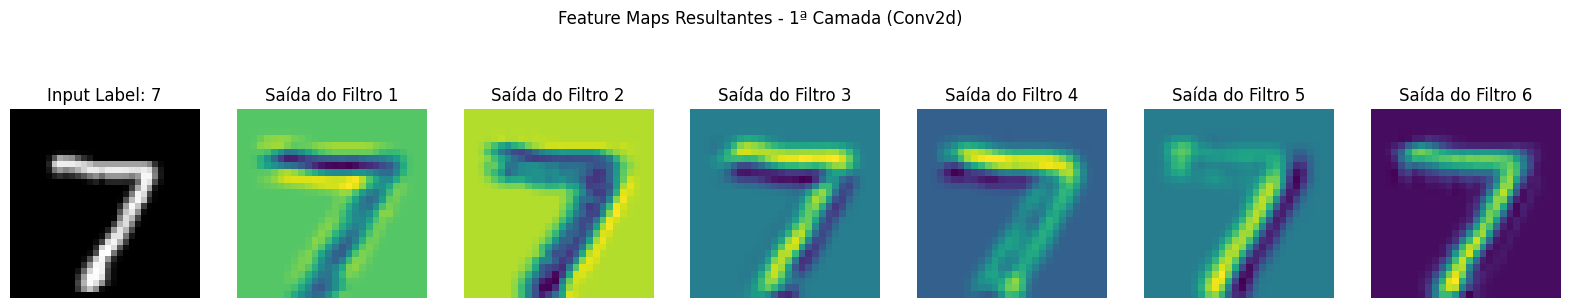

In [12]:
# Vamos isolar a primeira subcamada do feature_extractor, que é a nn.Conv2d de 6 filtros
first_conv_layer = model.feature_extractor[0]

model.eval() # Modo de avaliação
with torch.no_grad():
    # Carregando um lote do teste e pegando apenas a primeira imagem disponível
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    imgToVisualize = images[0].unsqueeze(0).to(device)  # Põe o Batch_Size=1 -> (1, 1, 32, 32)
    imgLabel = labels[0].item()
    
    # Passando a imagem APENAS pela primeira camada Conv2d
    feature_maps = first_conv_layer(imgToVisualize)
    
    # O formato da saída esperado será [1, 6, 28, 28], pois o kernel=5 sem padding reduz os lados.
    # Removemos a dimensão do batch => [6, 28, 28]
    feature_maps = feature_maps.squeeze(0).cpu().numpy()

# Exibindo a imagem verdadeira lado a lado com as 6 ativações de seus filtros
fig, axes = plt.subplots(1, 7, figsize=(20, 4))

# Plotando a Imagem Original de Entrada
original_img = imgToVisualize.squeeze(0).cpu().numpy().transpose(1, 2, 0)
axes[0].imshow(original_img, cmap='gray')
axes[0].set_title(f"Input Label: {imgLabel}")
axes[0].axis('off')

# Plotando as 6 Saídas dos Filtros da Camada 1
for i in range(1, 7):
    axes[i].imshow(feature_maps[i-1], cmap='viridis')
    axes[i].set_title(f"Saída do Filtro {i}")
    axes[i].axis('off')

plt.suptitle("Feature Maps Resultantes - 1ª Camada (Conv2d)")
plt.show()

## Salvando o Modelo
Após o treinamento, para garantir que as valiosas predições ajustadas não se percam, vamos extrair e gravar sua `state_dict()` (o dicionário de cada peso nas conexões) na nossa máquina isoladamente.

In [ ]:
# Define um caminho (path) base para salvar o arquivo
PATH = './lenet5_mnist_model.pth'

# Salvando o estado dos pesos do Modelo TREINADO
torch.save(model.state_dict(), PATH)
print(f"Modelo salvo com sucesso em {PATH}!")

## Carregando o Modelo
Para carregar, instanciamos novamente a estrutura da arquitetura original LeNet5 limpa e sobrepomos o 'state dict' com os pesos do modelo que carregamos com o `torch.load` previamente gravados no disco.

In [ ]:
# Carregando o modelo salvo posteriormente na mesma estrutura
# Para carregar, nós precisamos primeiro instanciar a mesma classe da rede que foi originalmente salva
loaded_model = LeNet5()

# Neste ponto o 'loaded_model' está recém-nascido com pesos aleatórios.
# Vamos populá-lo lendo os dicionários de parâmetros salvos no drive
loaded_model.load_state_dict(torch.load(PATH, weights_only=True))
loaded_model.eval() # Definimos para avaliação indicando que paramos de treinar

print("Modelo carregado do disco com sucesso e pronto para uso!")

# (Opcional) Teste Rápido: Passando 1 imagem pelo modelo recém-carregado apenas pra ver as saídas
with torch.no_grad():
    # Carregamos do dataset os exemplos
    dataiter = iter(test_loader)
    images, labels = next(dataiter)
    
    # Escolhemos só a 1ª imagem do lote
    first_image = images[0].unsqueeze(0) # Unsqueeze adiciona batch dimensão: [1, 1, 32, 32]
    first_label = labels[0]
    
    # Vamos exibir essa imagem
    plt.imshow(first_image[0, 0].numpy(), cmap='gray')
    plt.title(f"Real Label: {first_label.item()}")
    plt.axis('off')
    plt.show()
    
    # Previsão da Rede Carregada
    outputs = loaded_model(first_image)
    _, predicted = torch.max(outputs, 1)
    print(f"Previsão da Rede Recém-Carregada: {predicted.item()}")